# Análisis exploratorio: precios de autos usados

Este notebook explora el conjunto de datos **Regression of Used Car Prices**, publicado en Kaggle para la competencia Playground Series S4E9. El problema consiste en estimar el precio de venta de un automóvil usado a partir de sus características; por tanto, el objetivo de un futuro modelo será `price` y el tipo de problema es **regresión**.

El análisis revisa la calidad, distribución y relaciones de las variables antes de tomar decisiones de preprocesamiento. No entrena modelos ni modifica el archivo fuente. La primera celda de código importa las bibliotecas solicitadas, fija `RANDOM_STATE = 42` y configura las visualizaciones.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"


## Carga inicial

Se carga una copia de trabajo desde la ruta relativa del notebook. Primero se comprueba la dimensión, las columnas y una muestra de registros para confirmar que el archivo esperado se leyó correctamente; el CSV original permanece intacto.


In [3]:
from pathlib import Path

DATA_PATH = Path("../data/train.csv")
df = pd.read_csv(DATA_PATH)

print(f"Archivo cargado: {DATA_PATH.resolve()}")
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
display(df.head())


Archivo cargado: C:\Users\juanc\Documents\GitHub\Proyecto-Semestral-Modelos-I\fase-1\data\train.csv
Dimensiones: 188,533 filas x 13 columnas


,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


La lectura confirma que el archivo contiene **188,533 filas y 13 columnas**, con el objetivo `price` presente. La muestra sirve para inspeccionar el formato, pero no para inferir distribuciones; las conclusiones siguientes usan el conjunto completo.

## Descripción del dataset

El siguiente resumen separa el tipo inferido por pandas del papel analítico de cada campo. `id` es un identificador aunque esté almacenado como entero; no representa una magnitud del vehículo.


In [4]:
assert "price" in df.columns, "No se encontró la variable objetivo 'price'."

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

roles = {}
for column in df.columns:
    if column == "id":
        roles[column] = "Identificador (descartar como predictor)"
    elif column == "price":
        roles[column] = "Objetivo numérico (regresión)"
    elif column in numeric_cols:
        roles[column] = "Predictora numérica"
    else:
        roles[column] = "Predictora categórica / texto"

schema = pd.DataFrame({
    "variable": df.columns,
    "tipo pandas": [str(df[column].dtype) for column in df.columns],
    "tipo analítico": [roles[column] for column in df.columns],
})
display(schema)
print(f"Predictores numéricos: { [c for c in numeric_cols if c not in ['id', 'price']] }")
print(f"Predictores categóricos/texto: {categorical_cols}")


,variable,tipo pandas,tipo analítico
0,id,int64,Identificador (descartar como predictor)
1,brand,str,Predictora categórica / texto
2,model,str,Predictora categórica / texto
3,model_year,int64,Predictora numérica
4,milage,int64,Predictora numérica
5,fuel_type,str,Predictora categórica / texto
6,engine,str,Predictora categórica / texto
7,transmission,str,Predictora categórica / texto
8,ext_col,str,Predictora categórica / texto
9,int_col,str,Predictora categórica / texto


Predictores numéricos: ['model_year', 'milage']
Predictores categóricos/texto: ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']


Hay **dos variables numéricas predictoras** (`model_year` y `milage`), además de `id`, que solo identifica registros, y varias variables categóricas o de texto; `price` es el objetivo numérico. El precio observado va de autos económicos a vehículos de lujo, por lo que las medias y escalas pueden estar dominadas por valores extremos. El conjunto también puede reflejar sesgos de selección del mercado y categorías escritas de forma heterogénea.

## Valores faltantes

Se cuantifica la ausencia por columna, se visualiza su porcentaje y se compara el precio medio entre filas con y sin nulo para cada predictor afectado. Esa comparación detecta asociaciones descriptivas, no demuestra por sí sola que el mecanismo de ausencia no sea aleatorio ni una relación causal.


,nulos,porcentaje
clean_title,21419,11.361%
fuel_type,5083,2.696%
accident,2452,1.301%
brand,0,0.000%
id,0,0.000%
milage,0,0.000%
model_year,0,0.000%
model,0,0.000%
engine,0,0.000%
ext_col,0,0.000%


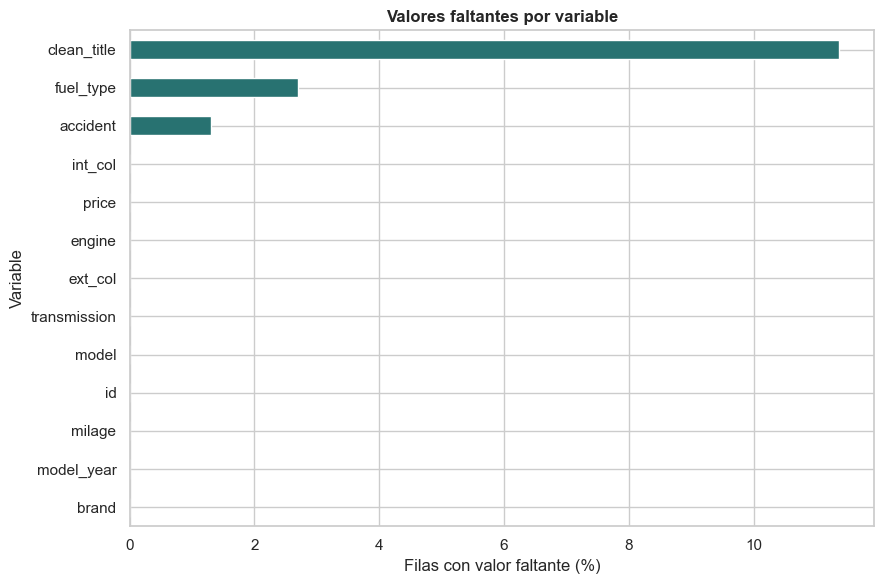

Predictores con entre 0.1% y 2% de nulos: ['accident']


,variable,filas con nulo,precio medio sin nulo,precio medio con nulo,diferencia (con - sin)
0,fuel_type,5083,43408.518327,60822.612040,17414.093714
1,accident,2452,43732.739479,54902.988989,11170.249510
2,clean_title,21419,41354.406704,63567.566273,22213.159569


In [6]:
missing_table = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": df.isna().mean().mul(100),
}).sort_values("porcentaje", ascending=False)
missing_display = missing_table.copy()
missing_display["porcentaje"] = missing_display["porcentaje"].map("{:.3f}%".format)
display(missing_display)

ax = missing_table["porcentaje"].sort_values().plot(kind="barh", color="#287271", figsize=(9, 6))
ax.set(title="Valores faltantes por variable", xlabel="Filas con valor faltante (%)", ylabel="Variable")
plt.tight_layout()
plt.show()

predictor_cols = [column for column in df.columns if column not in ["id", "price"]]
missing_in_range = missing_table.loc[
    missing_table.index.isin(predictor_cols)
    & missing_table["porcentaje"].between(0.1, 2.0)
].index.tolist()
print("Predictores con entre 0.1% y 2% de nulos:", missing_in_range or "Ninguno")

price_missing_rows = []
for column in predictor_cols:
    null_mask = df[column].isna()
    if null_mask.any():
        mean_without = df.loc[~null_mask, "price"].mean()
        mean_with = df.loc[null_mask, "price"].mean()
        price_missing_rows.append({
            "variable": column,
            "filas con nulo": int(null_mask.sum()),
            "precio medio sin nulo": mean_without,
            "precio medio con nulo": mean_with,
            "diferencia (con - sin)": mean_with - mean_without,
        })
price_by_missing = pd.DataFrame(price_missing_rows)
display(price_by_missing)


El mayor faltante está en `clean_title` (**11.36%**), seguido por `fuel_type` (**2.70%**) y `accident` (**1.30%**). La única predictora dentro del intervalo solicitado de **0.1% a 2%** es `accident`. En las tres variables, las filas con nulo muestran un precio medio superior al de las filas completas; por ejemplo, `clean_title` presenta aproximadamente **$63,568 frente a $41,354**. Esto sugiere que la ausencia puede contener señal o reflejar subgrupos distintos, pero la comparación marginal no prueba por sí sola el mecanismo de ausencia. En particular, `None reported` en `accident` es una categoría observada y no debe confundirse con un nulo.

## Estadísticas numéricas y valores atípicos

Se resumen `model_year`, `milage` y `price`, y se cuentan observaciones fuera de los límites de 1.5 veces el rango intercuartílico (IQR). Los boxplots ocultan los puntos extremos únicamente para que la caja sea legible; los registros permanecen en `df` y el conteo IQR los incluye.


,count,mean,std,min,25%,50%,75%,max,skewness
model_year,188533.0,2015.829998,5.660967,1974.0,2013.0,2017.0,2020.0,2024.0,-1.044511
milage,188533.0,65705.295174,49798.158076,100.0,24115.0,57785.0,95400.0,405000.0,0.895062
price,188533.0,43878.016178,78819.522254,2000.0,17000.0,30825.0,49900.0,2954083.0,20.268453


,variable,límite inferior,límite superior,observaciones fuera de IQR,porcentaje fuera de IQR
0,model_year,"2,002.5","2,030.5",5132,2.72%
1,milage,"-82,812.5","202,327.5",1766,0.94%
2,price,"-32,350.0","99,250.0",10880,5.77%


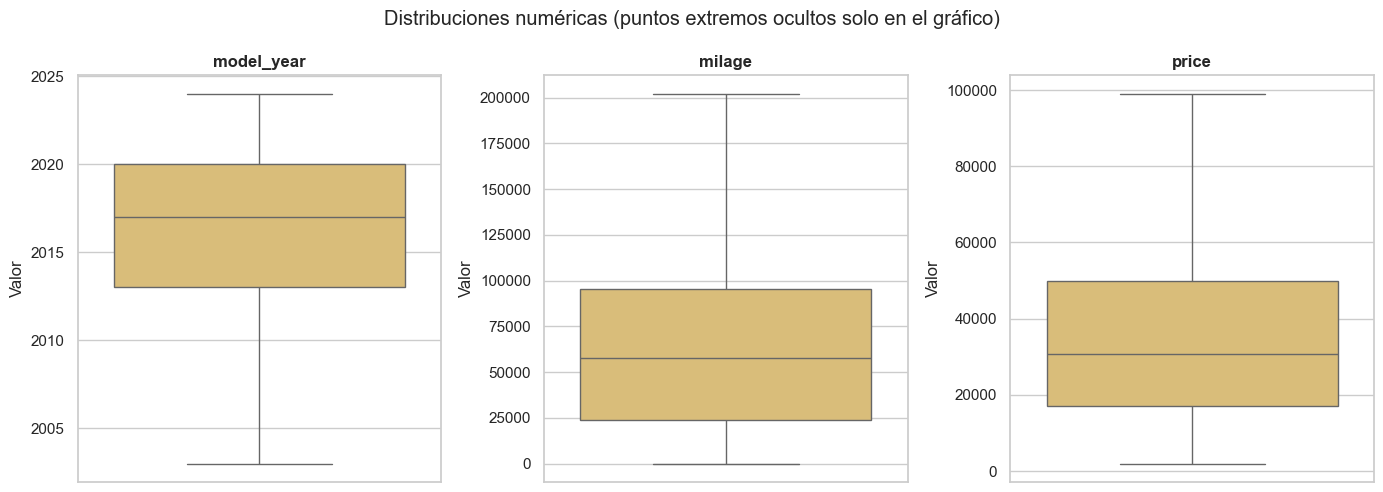

In [8]:
numeric_summary = df[["model_year", "milage", "price"]].describe().T
numeric_summary["skewness"] = df[["model_year", "milage", "price"]].skew()
display(numeric_summary)

iqr_rows = []
for column in ["model_year", "milage", "price"]:
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = int(((df[column] < lower) | (df[column] > upper)).sum())
    iqr_rows.append({
        "variable": column,
        "límite inferior": lower,
        "límite superior": upper,
        "observaciones fuera de IQR": count,
        "porcentaje fuera de IQR": count / len(df) * 100,
    })
iqr_table = pd.DataFrame(iqr_rows)
iqr_display = iqr_table.copy()
for column in ["límite inferior", "límite superior"]:
    iqr_display[column] = iqr_display[column].map("{:,.1f}".format)
iqr_display["porcentaje fuera de IQR"] = iqr_display["porcentaje fuera de IQR"].map("{:.2f}%".format)
display(iqr_display)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for axis, column in zip(axes, ["model_year", "milage", "price"]):
    sns.boxplot(y=df[column], ax=axis, color="#e9c46a", showfliers=False)
    axis.set_title(column)
    axis.set_ylabel("Valor")
fig.suptitle("Distribuciones numéricas (puntos extremos ocultos solo en el gráfico)")
plt.tight_layout()
plt.show()


El método IQR marca aproximadamente **5,132** observaciones de `model_year`, **1,766** de `milage` y **10,880** de `price` fuera de sus límites. Son candidatos para inspección, no necesariamente errores: en autos usados, antigüedad, kilometraje y precio extremos pueden ser legítimos y relevantes para el dominio.

## Distribución del objetivo

Se comparan el precio en escala original y `log1p(price)`. El sesgo y los histogramas permiten evaluar si una transformación del objetivo puede facilitar el ajuste de modelos sensibles a la asimetría; la decisión final debe considerar también la métrica de evaluación y la interpretación en dólares.


Sesgo de price: 20.268
Sesgo de log1p(price): 0.108


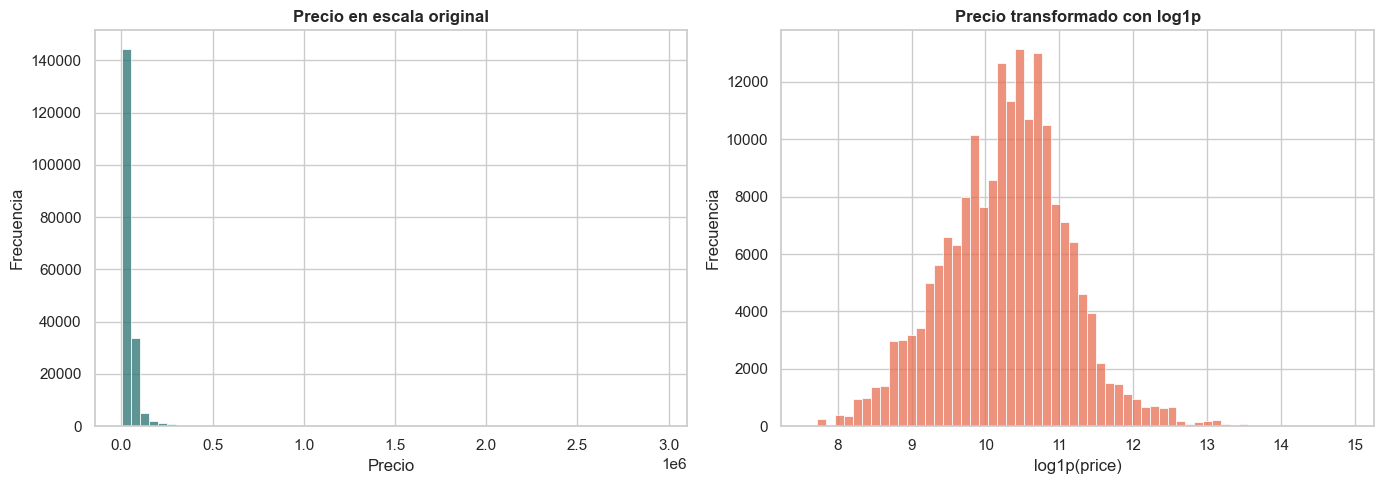

In [9]:
price_skew = df["price"].skew()
log_price = np.log1p(df["price"])
log_price_skew = log_price.skew()
print(f"Sesgo de price: {price_skew:.3f}")
print(f"Sesgo de log1p(price): {log_price_skew:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["price"], bins=60, ax=axes[0], color="#287271")
axes[0].set(title="Precio en escala original", xlabel="Precio", ylabel="Frecuencia")
sns.histplot(log_price, bins=60, ax=axes[1], color="#e76f51")
axes[1].set(title="Precio transformado con log1p", xlabel="log1p(price)", ylabel="Frecuencia")
plt.tight_layout()
plt.show()


`price` tiene un sesgo de **20.27**, mientras que `log1p(price)` queda cerca de simétrico (**0.108**). La transformación reduce claramente la cola derecha y conviene evaluarla como alternativa de objetivo en la validación posterior. Si se utiliza, las predicciones deben volver a la escala monetaria antes de compararlas con métricas expresadas en dólares, considerando que la inversión directa del log puede introducir sesgo.

## Variables categóricas

Se calcula la cardinalidad de las ocho variables categóricas solicitadas. Para las de cardinalidad alta se muestran las diez categorías más frecuentes; esto permite dimensionar la dispersión sin imprimir cientos o miles de niveles.


In [10]:
categorical_columns = [
    "brand", "model", "fuel_type", "transmission",
    "ext_col", "int_col", "accident", "clean_title",
]
cardinality = pd.DataFrame({
    "variable": categorical_columns,
    "categorías distintas": [df[column].nunique(dropna=True) for column in categorical_columns],
    "valores faltantes": [int(df[column].isna().sum()) for column in categorical_columns],
}).sort_values("categorías distintas", ascending=False)
display(cardinality)

high_cardinality = cardinality.loc[
    cardinality["categorías distintas"] >= 50, "variable"
].tolist()
print("Top 10 categorías para variables con cardinalidad >= 50:")
for column in high_cardinality:
    top_categories = df[column].value_counts(dropna=False).head(10)
    print(f"\n{column} ({df[column].nunique(dropna=True)} categorías)")
    display(top_categories.rename_axis("categoría").to_frame("frecuencia"))


,variable,categorías distintas,valores faltantes
1,model,1897,0
4,ext_col,319,0
5,int_col,156,0
0,brand,57,0
3,transmission,52,0
2,fuel_type,7,5083
6,accident,2,2452
7,clean_title,1,21419


Top 10 categorías para variables con cardinalidad >= 50:

model (1897 categorías)


,frecuencia
categoría,
F-150 XLT,2945
M3 Base,2229
Camaro 2SS,1709
M4 Base,1622
Mustang GT Premium,1526
F-150 Lariat,1410
E-Class E 350 4MATIC,1357
1500 Laramie,1249
911 Carrera S,1219



ext_col (319 categorías)


,frecuencia
categoría,
Black,48658
White,43815
Gray,25293
Silver,16995
Blue,14555
Red,9901
Green,2698
Gold,1668
Brown,1162


...

,frecuencia
categoría,
Black,107674
Beige,24495
Gray,21204
Brown,5810
Red,5145
White,4743
–,4527
Jet Black,2398
Ebony,1833



brand (57 categorías)


,frecuencia
categoría,
Ford,23088
Mercedes-Benz,19172
BMW,17028
Chevrolet,16335
Audi,10887
Porsche,10612
Land,9525
Toyota,8850
Lexus,8643



transmission (52 categorías)


,frecuencia
categoría,
A/T,49904
8-Speed A/T,20645
Transmission w/Dual Shift Mode,19255
6-Speed A/T,18044
6-Speed M/T,11998
7-Speed A/T,11124
Automatic,10691
8-Speed Automatic,8431
10-Speed A/T,8044


La cardinalidad observada varía desde **1 nivel** en `clean_title` hasta **1,897** en `model`; `brand`, `transmission`, `ext_col` e `int_col` también tienen al menos 50 niveles. `clean_title` solo contiene `Yes` entre sus valores observados, de modo que no permite comparar precios por categoría sin considerar sus nulos como un estado distinto. Entre los niveles más frecuentes destacan `F-150 XLT` en `model` (2,945 filas), `Black` en `ext_col` (48,658) e `int_col` (107,674), `Ford` en `brand` (23,088) y `A/T` en `transmission` (49,904), lo que muestra una concentración desigual de categorías.

Para visualizar asociaciones sin saturar los ejes, se grafican los niveles más frecuentes de cada variable con más de una categoría. Los boxplots usan escala logarítmica en el eje del precio y omiten puntos extremos solo en la figura; el precio original no se modifica.


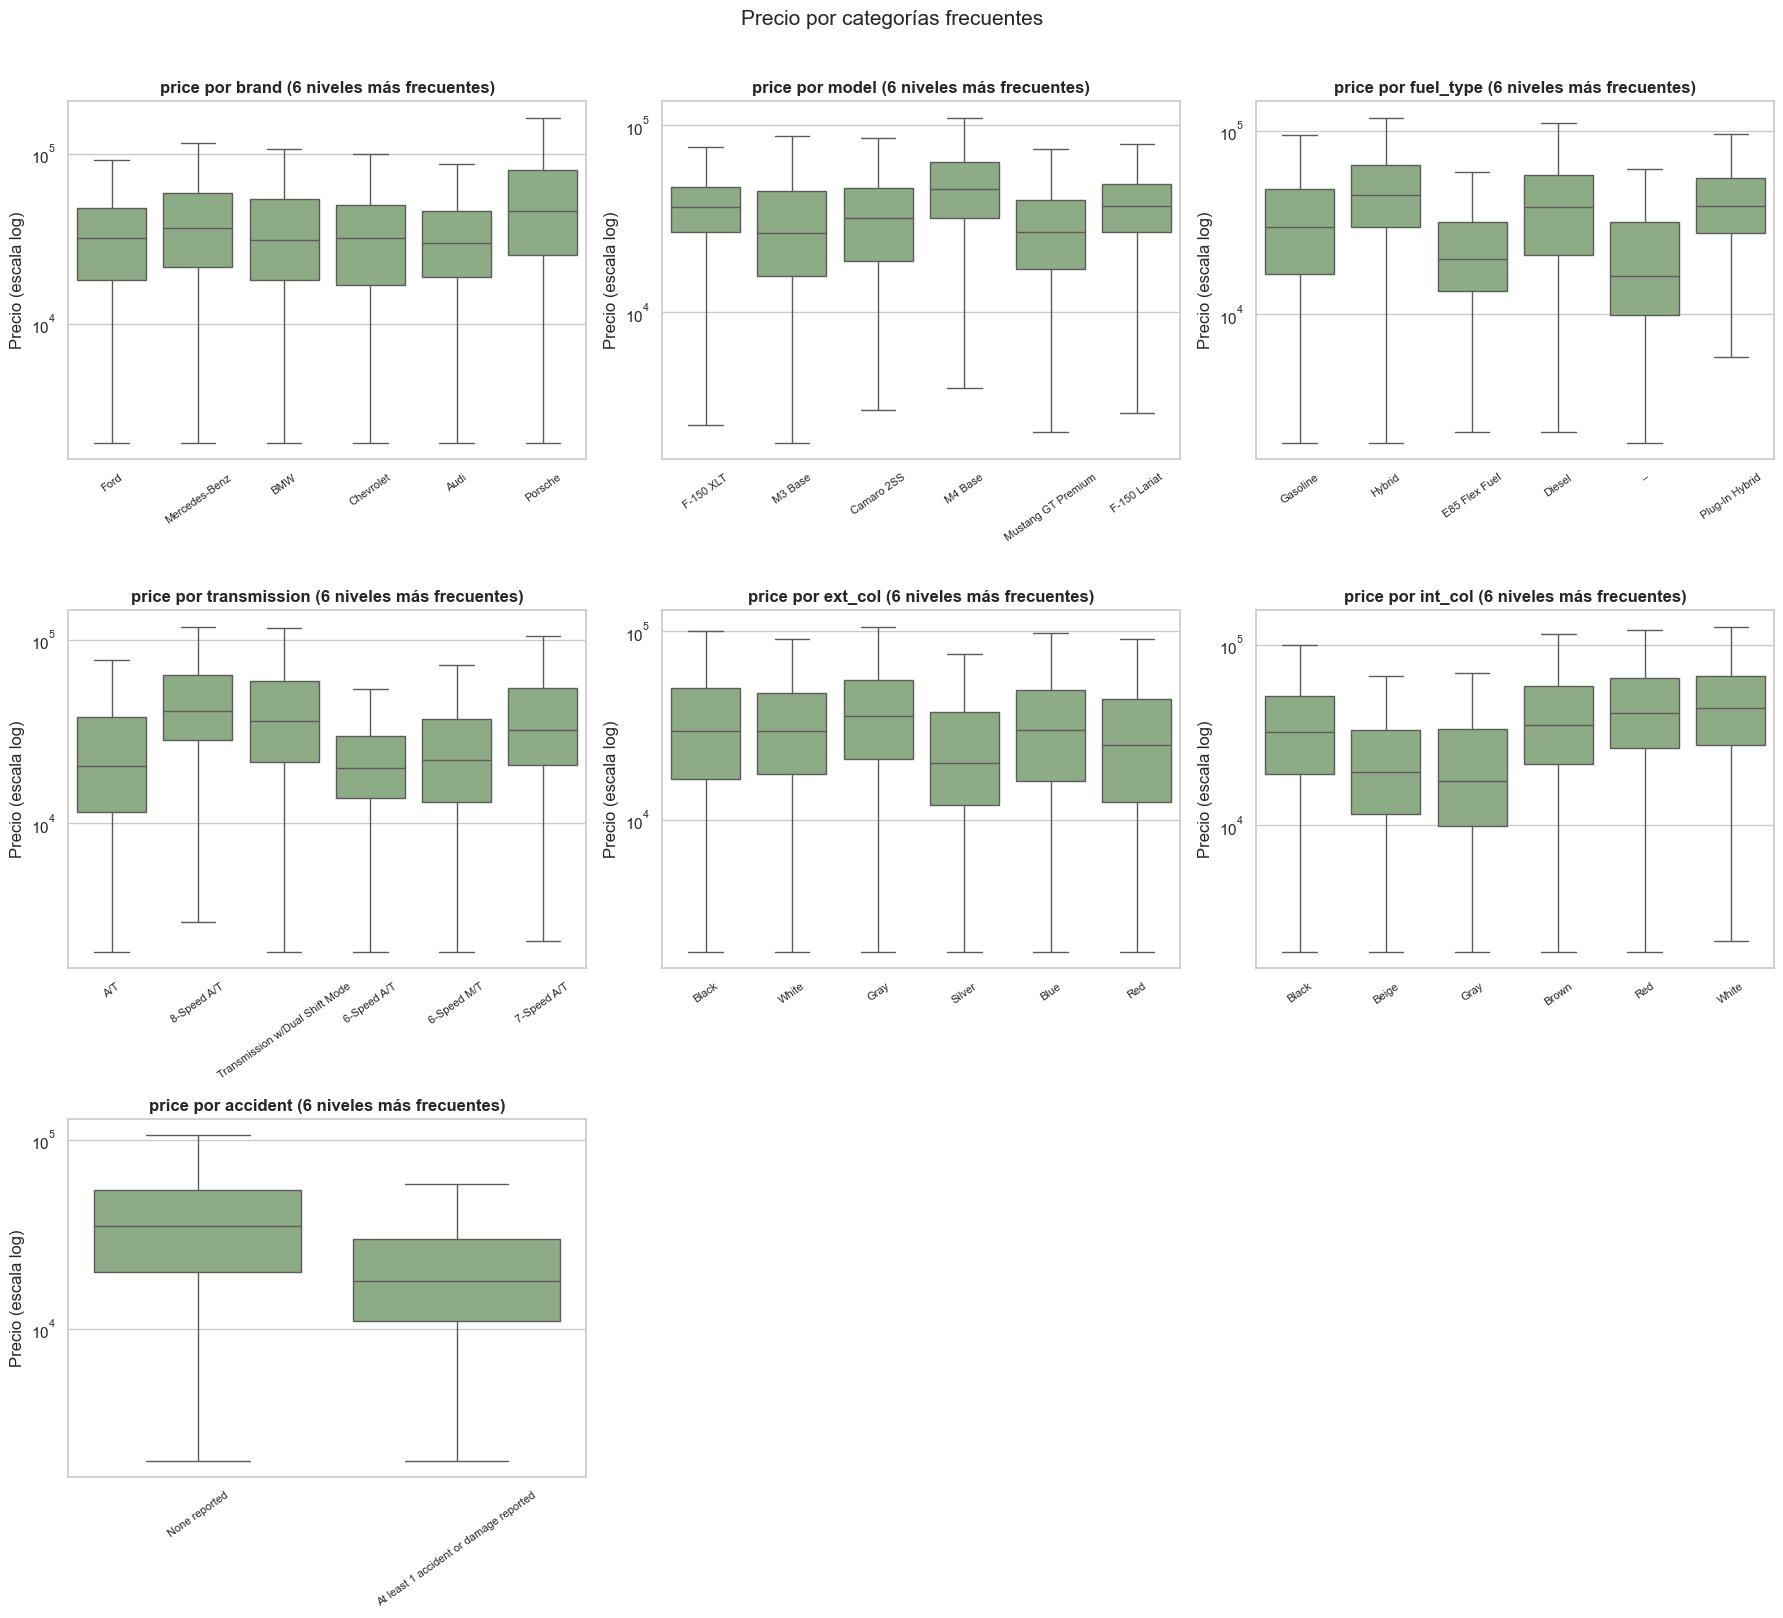

In [11]:
plot_columns = [
    "brand", "model", "fuel_type", "transmission", "ext_col", "int_col", "accident",
]
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
for axis, column in zip(axes.flat, plot_columns):
    levels = df[column].value_counts(dropna=True).head(6).index.tolist()
    plot_data = df.loc[df[column].isin(levels), [column, "price"]]
    sns.boxplot(
        data=plot_data,
        x=column,
        y="price",
        order=levels,
        showfliers=False,
        color="#8ab17d",
        ax=axis,
    )
    axis.set_yscale("log")
    axis.set_title(f"price por {column} (6 niveles más frecuentes)")
    axis.set_xlabel("")
    axis.set_ylabel("Precio (escala log)")
    axis.tick_params(axis="x", rotation=35, labelsize=8)
for axis in axes.flat[len(plot_columns):]:
    axis.set_visible(False)
fig.suptitle("Precio por categorías frecuentes", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()


Las distribuciones muestran diferencias relevantes entre categorías frecuentes, aunque con solapamiento y sin controlar por año, kilometraje, marca u otras características. Por ejemplo, la mediana de `price` es **$35,000** para `None reported` y **$18,000** para `At least 1 accident or damage reported`; esto respalda conservar la distinción de accidente como predictor, no interpretarla como efecto causal. En `clean_title`, la comparación entre valores observados sigue siendo imposible porque solo aparece `Yes`.

## Texto de `engine` y `transmission`

Estos campos son cadenas descriptivas con patrones parcialmente estructurados. Se inspeccionan sus valores más frecuentes; la extracción de atributos se deja como recomendación para una fase posterior y no se implementa en este notebook.


In [12]:
for column in ["engine", "transmission"]:
    counts = df[column].value_counts(dropna=False).head(15)
    frequency_table = counts.rename_axis("valor observado").to_frame("frecuencia")
    frequency_table["porcentaje del dataset"] = frequency_table["frecuencia"] / len(df) * 100
    frequency_table["porcentaje del dataset"] = frequency_table["porcentaje del dataset"].map("{:.2f}%".format)
    print(f"Valores más frecuentes de {column}:")
    display(frequency_table)


Valores más frecuentes de engine:


,frecuencia,porcentaje del dataset
valor observado,,
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,3462,1.84%
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,2902,1.54%
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2841,1.51%
2.0L I4 16V GDI DOHC Turbo,2680,1.42%
375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,2451,1.30%
340.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,2436,1.29%
490.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2187,1.16%
455.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2138,1.13%
425.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel,2134,1.13%


Valores más frecuentes de transmission:


,frecuencia,porcentaje del dataset
valor observado,,
A/T,49904,26.47%
8-Speed A/T,20645,10.95%
Transmission w/Dual Shift Mode,19255,10.21%
6-Speed A/T,18044,9.57%
6-Speed M/T,11998,6.36%
7-Speed A/T,11124,5.90%
Automatic,10691,5.67%
8-Speed Automatic,8431,4.47%
10-Speed A/T,8044,4.27%


Los ejemplos de `engine` muestran patrones como `355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel`; potencialmente describen **potencia (HP)**, **cilindrada (L)**, **número de cilindros** y **tipo de combustible/motor**. En `transmission`, valores como `8-Speed A/T` o `6-Speed M/T` sugieren **número de velocidades** y **tipo de transmisión** (automática/manual). Los formatos no son uniformes, por lo que cualquier extracción futura requeriría reglas, categorías no reconocidas y validación; aquí solo se describen, no se extraen.

## Correlación entre variables numéricas

La matriz se limita a `model_year`, `milage` y `price`; `id` se excluye por ser un identificador sin significado cuantitativo para la relación entre características del vehículo. La correlación de Pearson resume asociación lineal y no descarta relaciones no lineales.


,model_year,milage,price
model_year,1.000,-0.670,0.232
milage,-0.670,1.000,-0.283
price,0.232,-0.283,1.000


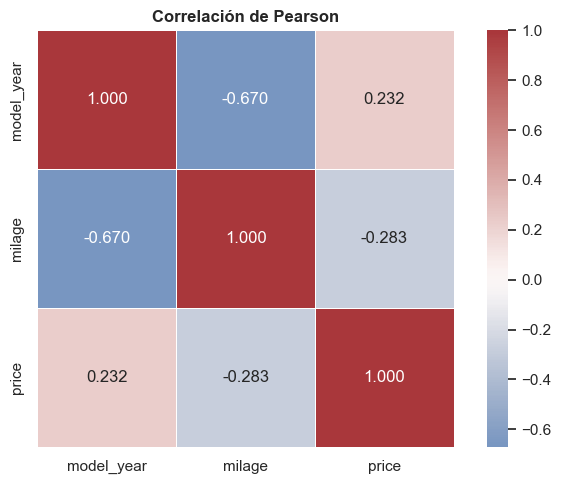

In [13]:
correlation_columns = ["model_year", "milage", "price"]
correlation_matrix = df[correlation_columns].corr(method="pearson")
display(correlation_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlación de Pearson")
plt.tight_layout()
plt.show()


`model_year` y `milage` presentan correlación inversa de **−0.670**: los autos más nuevos tienden a tener menos kilometraje, pero la relación no es redundancia perfecta. Sus correlaciones con `price` son **0.232** y **−0.283**, respectivamente, lo que indica asociaciones lineales moderadas o débiles y deja espacio para efectos no lineales e interacciones. Se justifica conservar ambas para el modelado y excluir `id`; cualquier transformación debe evaluarse con validación, no decidirse solo por esta matriz.

## Conclusiones y decisiones recomendadas

Las siguientes decisiones son recomendaciones para la fase de preprocesamiento, no transformaciones ejecutadas aquí. Deben ajustarse usando únicamente el conjunto de entrenamiento de cada partición para evitar fuga de información.

- `fuel_type` (2.70% de nulos): conservar como categórica; representar los faltantes como `Desconocido` o con imputación categórica más indicador. Revisar y normalizar niveles raros o caracteres no estándar antes de agrupar categorías.
- `accident` (1.30% de nulos): conservar; distinguir el faltante como `Desconocido` y mantener `None reported` separado, pues el precio medio difiere entre filas con y sin nulo.
- `clean_title` (11.36% de nulos): conservar la señal de ausencia como categoría/indicador; entre valores no nulos solo aparece `Yes`, por lo que la columna observada no aporta variación y podría descartarse después de crear el indicador de faltante.
- `id`: descartar como predictor; es un identificador y puede inducir asociaciones espurias.
- `model_year` y `milage`: conservar ambas. Revisar límites y consistencia, y considerar derivar antigüedad del vehículo; no eliminar una por su correlación de −0.670.
- Valores atípicos en `model_year`, `milage` y `price`: inspeccionar plausibilidad y errores, pero no eliminarlos solo por la regla IQR. Comparar modelos robustos y, si hay evidencia, evaluar tratamiento dentro de cada partición.
- `engine`: en una fase posterior evaluar extraer potencia en HP, cilindrada en litros, número de cilindros y tipo de combustible/motor; validar cobertura y formatos no reconocidos.
- `transmission`: normalizar y evaluar derivar tipo (automática/manual u otra) y número de velocidades; conservar una categoría de respaldo para formatos no interpretables.
- Categóricas de alta cardinalidad (`model`, colores, `brand`, `transmission`): comparar codificación apropiada y agrupación de niveles infrecuentes, aprendiendo reglas solo con entrenamiento.
- `price`: probar `log1p(price)` en validación, dado el sesgo 20.27 frente a 0.108 en escala logarítmica. Invertir la transformación al reportar errores en dólares y revisar el sesgo introducido al volver a la escala original.

El dataset original no se altera: todas las tablas y gráficos se calculan sobre `df` en memoria y no hay entrenamiento ni escritura de datos.
